In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.utils.data
from torch.utils.data import DataLoader
from PIL import Image
from matplotlib import pyplot as plt
import seaborn as sns
import wandb
import math
import argparse
import datetime
import math
from time import time

In [2]:
import sys
from pathlib import Path

In [3]:
repo_root = Path.cwd()
ms_dir = repo_root / "multiscale diffusion"

if ms_dir.exists():
    sys.path.append(str(ms_dir))
elif (repo_root / "diffusion_score_models.py").exists():
    sys.path.append(str(repo_root))



In [4]:
import diffusion_score_models as score_models



In [5]:
from multiband_data_utils import (
    generate_multiband_dataset_postmask,
    add_fourier_bias_to_result,
    make_radial_band_mask,
    radial_bandpass,
    make_radial_k_grid,
)



In [6]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

components = [
    {"name": "coarse", "length_scale": 2.0,  "s": 2.0, "sigma_sq": 1.0, "band": (0.5, 4.0)},
    {"name": "mid1",   "length_scale": 6.0,  "s": 2.0, "sigma_sq": 1.0, "band": (4.0, 10.0)},
    {"name": "mid2",   "length_scale": 12.0, "s": 2.0, "sigma_sq": 1.0, "band": (10.0, 18.0)},
    {"name": "fine",   "length_scale": 24.0, "s": 2.0, "sigma_sq": 1.0, "band": (18.0, 32.0)},
]

result = generate_multiband_dataset_postmask(
    num_samples=200,
    grid_size=128,
    components=components,
    weights=[1.0, 0.8, 0.8, 1.2],
    seed=42,
    normalize=True,
)

result = add_fourier_bias_to_result(
    result,
    k0=26.0,
    width=2.0,
    strength=0.10,
    seed=123,
    overwrite_combined=False,
)

bands = result.get("bands", {c["name"]: c["band"] for c in components})
x_unbiased = result["combined"]
x_biased = result["combined_biased"]

analysis_source = "biased"  # set to "unbiased" to analyze clean training data
analysis_data = x_biased if analysis_source == "biased" else x_unbiased

B, N, _ = analysis_data.shape
print(f"device={device}, analysis_source={analysis_source}, samples={B}, grid={N}x{N}")



device=cpu, analysis_source=biased, samples=200, grid=128x128


In [7]:
n_train = 32
x_train_img = analysis_data[:n_train]      # (n_train, N, N)
x_holdout_img = analysis_data[n_train:]    # optional holdout

train_data = x_train_img.reshape(n_train, -1).contiguous().to(device)

diffusion_model = score_models.VP()
score_model = score_models.GMM_score(
    train_data,
    marginal_prob_mean=diffusion_model.marginal_prob_mean,
    marginal_prob_std=diffusion_model.marginal_prob_std,
).to(device)



In [8]:
n_samples = 16
latents = torch.randn(n_samples, train_data.shape[1], device=device)

samples = diffusion_model.SDEsampler(score_model, latents, num_steps=1000)
samples_img = samples.reshape(n_samples, 1, N, N)
x_gen = samples_img[:, 0]



In [9]:
@torch.no_grad()
def band_component(x, band, norm="forward"):
    # x: (B, N, N) or (N, N)
    if x.dim() == 2:
        x = x.unsqueeze(0)
    k_lo, k_hi = band
    m = make_radial_band_mask(x.shape[-1], k_lo, k_hi, device=x.device, dtype=x.dtype)
    return radial_bandpass(x, m, norm=norm)


@torch.no_grad()
def nn_by_coarse(x_gen, x_train, coarse_band):
    cg = band_component(x_gen, coarse_band).flatten(1)
    ct = band_component(x_train, coarse_band).flatten(1)
    D = torch.cdist(cg, ct)
    idx = D.argmin(dim=1)
    return idx, D.min(dim=1).values


def make_ring_masks(N, k_edges, device):
    kr = make_radial_k_grid(N, device=device)
    masks = []
    for lo, hi in zip(k_edges[:-1], k_edges[1:]):
        masks.append(((kr >= lo) & (kr < hi)).float())
    return torch.stack(masks, dim=0)


@torch.no_grad()
def ring_rel_l2(xa, xb, ring_masks, fft_norm=None, eps=1e-12):
    Xa = torch.fft.fft2(xa, dim=(-2, -1), norm=fft_norm)
    Xb = torch.fft.fft2(xb, dim=(-2, -1), norm=fft_norm)
    D = Xa - Xb

    rm = ring_masks.unsqueeze(0).to(Xa.device)
    num = (D.abs() ** 2).unsqueeze(1) * rm
    den = (Xa.abs() ** 2).unsqueeze(1) * rm
    num = num.sum(dim=(-2, -1))
    den = den.sum(dim=(-2, -1)).clamp_min(eps)
    return torch.sqrt(num / den)


@torch.no_grad()
def random_baseline_errors(xg, xtr, ring_masks, n_ref=64, fft_norm=None):
    errs = []
    for _ in range(n_ref):
        rand_idx = torch.randint(0, xtr.shape[0], (xg.shape[0],), device=xtr.device)
        errs.append(ring_rel_l2(xg, xtr[rand_idx], ring_masks, fft_norm=fft_norm))
    return torch.stack(errs, dim=0)  # (n_ref, G, K)



In [10]:
xtr = x_train_img.detach().to(device)
xg = x_gen.detach().to(device)

# (1) match each generated sample to nearest training sample in coarse band.
idx_nn, _ = nn_by_coarse(xg, xtr, bands["coarse"])
xnn = xtr[idx_nn]

# (2) ring-wise closeness vs NN, normalized by averaged random-training baseline.
kmax = float(make_radial_k_grid(N, device=device).max().item())
k_edges = torch.arange(0.5, kmax + 1.5, 1.0, device=device)
ring_masks = make_ring_masks(N, k_edges, device=device)
k_centers = 0.5 * (k_edges[1:] + k_edges[:-1])

err_nn = ring_rel_l2(xg, xnn, ring_masks, fft_norm=None)  # (G, K)

n_rand_ref = 64
err_rand_refs = random_baseline_errors(xg, xtr, ring_masks, n_ref=n_rand_ref, fft_norm=None)  # (R, G, K)
ratio_refs = err_nn.unsqueeze(0) / (err_rand_refs + 1e-12)

ratio = ratio_refs.mean(dim=0)  # (G, K)
ratio_std = ratio_refs.std(dim=0, unbiased=False)
mean_ratio = ratio.mean(dim=0)



In [14]:
def ring_idx_for_band(band):
    lo, hi = band
    return ((k_centers >= lo) & (k_centers < hi)).nonzero().squeeze(1)


coarse_r = ring_idx_for_band(bands["coarse"])
fine_r = ring_idx_for_band(bands["fine"])

coarse_score = ratio[:, coarse_r].mean(dim=1)
fine_score = ratio[:, fine_r].mean(dim=1)

print("coarse score mean/median:", coarse_score.mean().item(), coarse_score.median().item())
print("fine score mean/median:", fine_score.mean().item(), fine_score.median().item())

for thr in [0.5, 0.7, 0.9]:
    coarse_mem = (coarse_score < thr)
    fine_mem = (fine_score < thr)
    print(f"fraction coarse_mem (<{thr}):", coarse_mem.float().mean().item())
    print(f"fraction fine_mem   (<{thr}):", fine_mem.float().mean().item())

coarse_mem = (coarse_score < 0.7)
fine_novel = (fine_score > 1.0)
print("fraction coarse_mem(<0.7) AND fine_novel(>1.0):", (coarse_mem & fine_novel).float().mean().item())



coarse score mean/median: 0.02648046985268593 0.031348150223493576
fine score mean/median: 0.03688264265656471 0.041519735008478165
fraction coarse_mem (<0.5): 1.0
fraction fine_mem   (<0.5): 1.0
fraction coarse_mem (<0.7): 1.0
fraction fine_mem   (<0.7): 1.0
fraction coarse_mem (<0.9): 1.0
fraction fine_mem   (<0.9): 1.0
fraction coarse_mem(<0.7) AND fine_novel(>1.0): 0.0


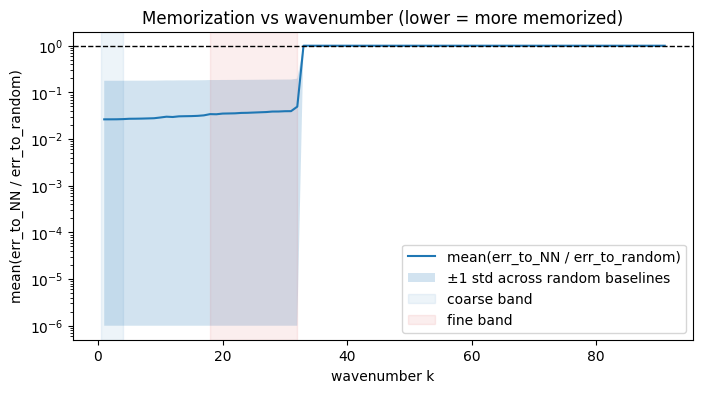

In [11]:
import matplotlib.pyplot as plt

kc = k_centers.detach().cpu().numpy()
mr = mean_ratio.detach().cpu().numpy()
mr_lo = torch.clamp(mean_ratio - ratio_std.mean(dim=0), min=1e-6).detach().cpu().numpy()
mr_hi = (mean_ratio + ratio_std.mean(dim=0)).detach().cpu().numpy()

plt.figure(figsize=(8, 4))
plt.plot(kc, mr, label="mean(err_to_NN / err_to_random)")
plt.fill_between(kc, mr_lo, mr_hi, alpha=0.2, label="±1 std across random baselines")
plt.axhline(1.0, linestyle="--", color="black", linewidth=1)

for band_name, color in [("coarse", "tab:blue"), ("fine", "tab:red")]:
    lo, hi = bands[band_name]
    plt.axvspan(lo, hi, color=color, alpha=0.08, label=f"{band_name} band")

plt.yscale("log")
plt.xlabel("wavenumber k")
plt.ylabel("mean(err_to_NN / err_to_random)")
plt.title("Memorization vs wavenumber (lower = more memorized)")
plt.legend()
plt.show()



In [12]:
@torch.no_grad()
def nn_l2_flat(xg, xtr):
    D = torch.cdist(xg.flatten(1), xtr.flatten(1))
    return D.min(dim=1).values, D.argmin(dim=1)

xtr = x_train_img.to(device)
xg  = x_gen.to(device)

d_pix, idx_pix = nn_l2_flat(xg, xtr)
print("pixel NN distance mean/median:", d_pix.mean().item(), d_pix.median().item())

# coarse-band NN distance (should be SMALL if coarse is memorized)
cg = band_component(xg,  bands["coarse"]).flatten(1)
ct = band_component(xtr, bands["coarse"]).flatten(1)
d_coarse = torch.cdist(cg, ct).min(dim=1).values
print("coarse-band NN dist mean/median:", d_coarse.mean().item(), d_coarse.median().item())

# fine-band NN distance (small means it’s also copying fine)
fg = band_component(xg,  bands["fine"]).flatten(1)
ft = band_component(xtr, bands["fine"]).flatten(1)
d_fine = torch.cdist(fg, ft).min(dim=1).values
print("fine-band NN dist mean/median:", d_fine.mean().item(), d_fine.median().item())

pixel NN distance mean/median: 0.3281601667404175 0.3284968137741089
coarse-band NN dist mean/median: 0.020739121362566948 0.0
fine-band NN dist mean/median: 0.12098264694213867 0.12077832221984863


In [13]:
eps = 1e-8

# assumes you already have xg, xtr, bands dict
cg = band_component(xg,  bands["coarse"]).flatten(1)
ct = band_component(xtr, bands["coarse"]).flatten(1)
dg = torch.cdist(cg, ct)
dmin_c, idx_c = dg.min(dim=1)

fg = band_component(xg,  bands["fine"]).flatten(1)
ft = band_component(xtr, bands["fine"]).flatten(1)
df = torch.cdist(fg, ft).min(dim=1).values

px = torch.cdist(xg.flatten(1), xtr.flatten(1)).min(dim=1).values

print("Frac exact coarse matches:", (dmin_c < eps).float().mean().item())
print("Frac exact fine matches  :", (df < eps).float().mean().item())
print("Frac exact pixel matches :", (px < eps).float().mean().item())

Frac exact coarse matches: 0.5
Frac exact fine matches  : 0.0
Frac exact pixel matches : 0.0


In [18]:
# check near-duplicates within training coarse
Dtt = torch.cdist(ct, ct)
Dtt.fill_diagonal_(1e9)
print("Min non-self coarse distance in train:", Dtt.min().item())
print("Frac near-duplicate coarse pairs (<1e-8):", (Dtt < 1e-8).float().mean().item())

Min non-self coarse distance in train: 113.99344635009766
Frac near-duplicate coarse pairs (<1e-8): 0.0
